# Day 03 - PyTorch Fundamentals

## Project
MNIST Handwritten Digit Classification

### Objectives
- Learn PyTorch tensors
- Load MNIST dataset
- Understand DataLoader
- Build first neural network
- Prepare for model training

In [1]:
import torch
import torchvision

print("PyTorch Version :", torch.__version__)
print("Torchvision Version :", torchvision.__version__)
print("CUDA Available :", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using Device :", device)

PyTorch Version : 2.11.0+cpu
Torchvision Version : 0.26.0+cpu
CUDA Available : False
Using Device : cpu


In [2]:
import torch

x = torch.tensor([
    [1,2,3],
    [4,5,6]
])

print(x)
print()

print("Shape :", x.shape)
print("Data Type :", x.dtype)
print("Dimension :", x.ndim)

tensor([[1, 2, 3],
        [4, 5, 6]])

Shape : torch.Size([2, 3])
Data Type : torch.int64
Dimension : 2


In [3]:
a = torch.tensor([1,2,3])
b = torch.tensor([4,5,6])

print("Addition")
print(a+b)

print()

print("Multiplication")
print(a*b)

print()

print("Mean")
print(torch.mean(a.float()))

Addition
tensor([5, 7, 9])

Multiplication
tensor([ 4, 10, 18])

Mean
tensor(2.)


In [4]:
x = torch.rand(3,4)

print(x)

tensor([[0.1678, 0.5043, 0.4353, 0.0355],
        [0.6173, 0.8472, 0.5485, 0.8465],
        [0.7510, 0.9744, 0.7040, 0.8783]])


In [5]:
from torchvision import datasets
from torchvision.transforms import ToTensor

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

print("Training Images :", len(train_dataset))
print("Testing Images :", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 43.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.25MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]

Training Images : 60000
Testing Images : 10000


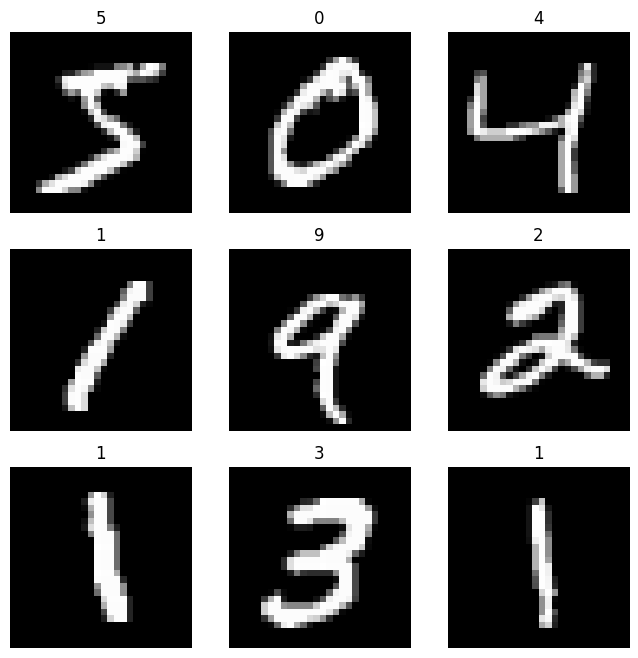

In [6]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(8,8))

for i in range(9):

    image, label = train_dataset[i]

    plt.subplot(3,3,i+1)

    plt.imshow(image.squeeze(), cmap="gray")

    plt.title(label)

    plt.axis("off")

plt.show()

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Train Loader Batches :", len(train_loader))
print("Test Loader Batches :", len(test_loader))

Train Loader Batches : 938
Test Loader Batches : 157


In [8]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [9]:
import torch.nn as nn

class MNISTModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

model = MNISTModel()

print(model)

MNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [10]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [11]:
sample_images, sample_labels = next(iter(train_loader))

outputs = model(sample_images)

print(outputs.shape)

torch.Size([64, 10])


In [12]:
predictions = torch.argmax(outputs, dim=1)

print("Predictions:")
print(predictions[:10])

print()

print("Actual Labels:")
print(sample_labels[:10])

Predictions:
tensor([3, 6, 6, 4, 6, 6, 3, 6, 3, 6])

Actual Labels:
tensor([3, 7, 9, 0, 2, 1, 3, 5, 0, 1])


In [13]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    accuracy = 100 * correct / total

    return epoch_loss, accuracy

In [14]:
num_epochs = 5

train_losses = []

train_accuracies = []

for epoch in range(num_epochs):

    loss, acc = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        device
    )

    train_losses.append(loss)

    train_accuracies.append(acc)

    print(
        f"Epoch {epoch+1}/{num_epochs}"
        f" | Loss = {loss:.4f}"
        f" | Accuracy = {acc:.2f}%"
    )

Epoch 1/5 | Loss = 0.3419 | Accuracy = 90.57%
Epoch 2/5 | Loss = 0.1363 | Accuracy = 95.96%
Epoch 3/5 | Loss = 0.0934 | Accuracy = 97.15%
Epoch 4/5 | Loss = 0.0701 | Accuracy = 97.86%
Epoch 5/5 | Loss = 0.0542 | Accuracy = 98.33%


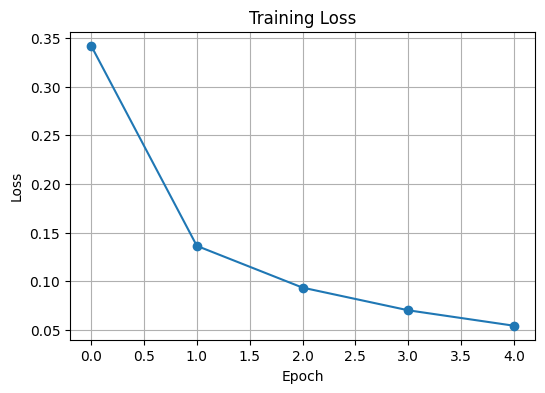

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(train_losses, marker="o")

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

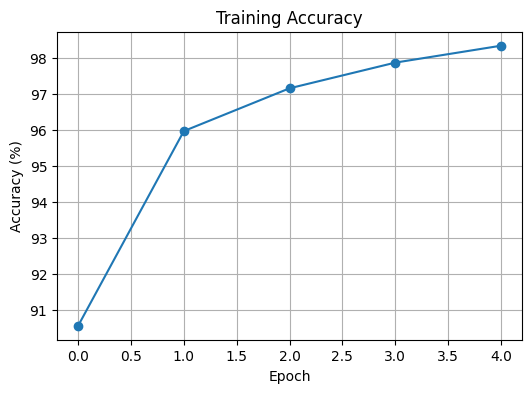

In [16]:
plt.figure(figsize=(6,4))

plt.plot(train_accuracies, marker="o")

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

In [17]:
model.eval()

correct = 0

total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

test_accuracy = 100 * correct / total

print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Accuracy : 97.53%


In [18]:
torch.save(model.state_dict(), "mnist_mlp.pth")

print("Model saved successfully!")

Model saved successfully!


## DAY 4 Summary

### What I Learned

- Training Loop
- Epoch
- Loss Function
- Backpropagation
- Optimizer
- Accuracy Evaluation
- Saving a PyTorch Model

### Final Results

- Number of Epochs:
- Final Training Accuracy:
- Final Test Accuracy:

### Reflection

The model improved its accuracy after several epochs because the optimizer updated the network weights using backpropagation, allowing it to learn patterns from the MNIST dataset.